# Testing the model on spots

## Spot generation

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("..")

import matplotlib.patches as patches
from matplotlib import colormaps as cmaps
import os
from tqdm import tqdm
import yaml
from importlib import reload  # Python 3.4+
import pandas as pd

import image_generator as ig

from yundon_functions import *
pi = np.pi
from multiprocessing import Pool
from PIL import Image
from cv2 import resize
from itertools import repeat
from matplotlib.patches import Rectangle, Circle
# %matplotlib widget
import cv2
from ultralytics.utils import ops


def plot_result(ax,img,objects, vmin=1.95e4, vmax=2.05e4):
    if isinstance(img, PIL.Image.Image) or isinstance(img, np.ndarray):
        pass
    elif(type(img) == str):
        img = PIL.Image.open(img)
    ax.imshow(img,cmap="grey",vmin=vmin,vmax=vmax)
    ax.axis("off")
    for i,obj in objects.iterrows():
        l,x,y,w,h = obj[:5]
        rect = Rectangle((x-0.5*w,y-0.5*h),h,w, linewidth=1, edgecolor="yellow", facecolor='none')
        tx,ty = rect.get_xy()
        ax.add_patch(rect)
        tx+=6
        ty-=12
        circle = Circle((x,y),1, facecolor="red",edgecolor="red")
        ax.add_patch(circle)
        if l == "Ripple":
            ax.text(tx,ty,f"{obj["z"]*0.134:.3f}",fontsize="small",bbox=dict(facecolor='white', alpha=0.5,))
def plot_gt(path,ax,imgsz=[512,512],vmin=1.95e4,vmax=2.05e4):
    data=np.atleast_2d(np.loadtxt(path.replace("images", "labels").replace("jpg","txt").replace("tif","txt"))).T
    # print(data)
    if(len(data)==0):
         return plot_result(ax,path, np.empty(0),np.empty((0,4)),np.empty(0),np.empty((0,0)),vmin=vmin,vmax=vmax)
    cls = data[0]
    bboxes = data[1:5].T*(imgsz*2)
    z = data[5]
    kpts = data[7:].T*imgsz
    # print(bboxes)
    
    return plot_result(ax,path, cls,bboxes,z,kpts, vmin=vmin,vmax=vmax)

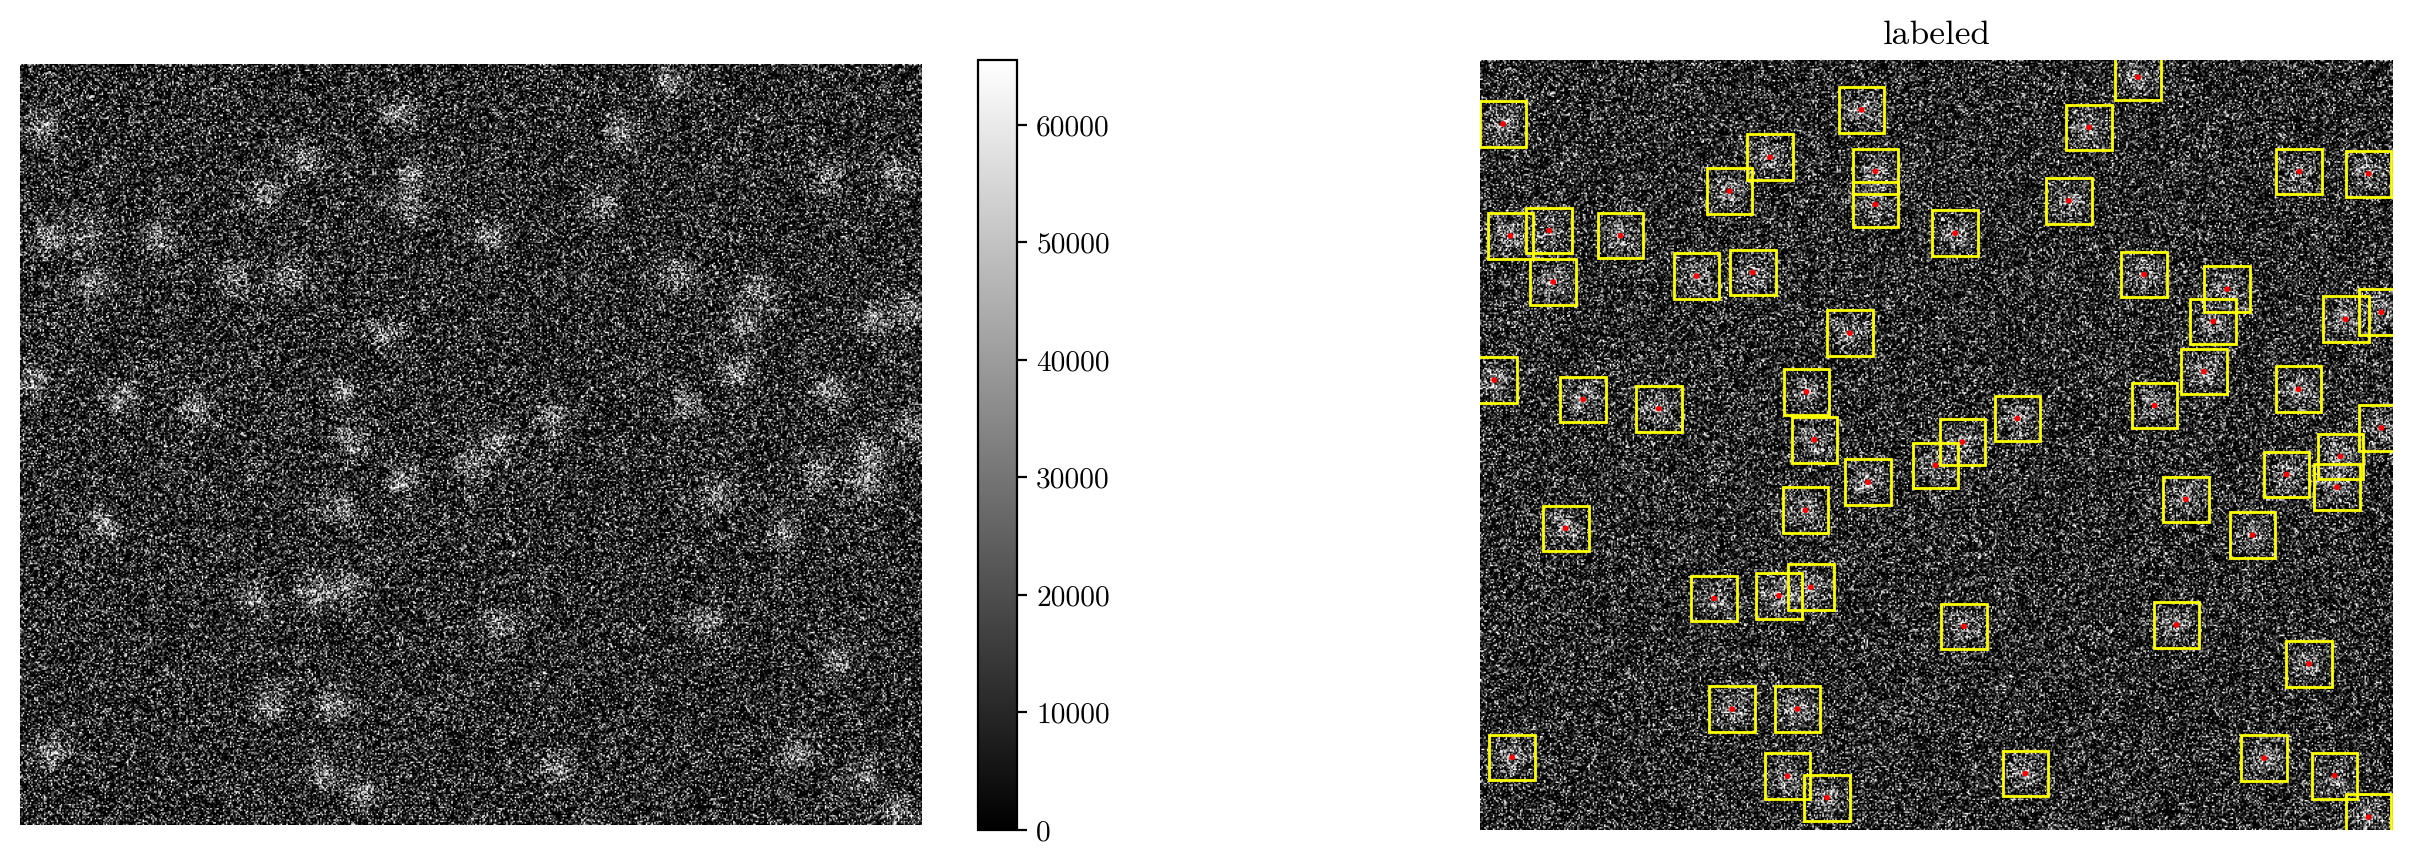

In [20]:
spot_params = {"label":"Spot", "i":("gaussian", [2**15]), "s":8, "n":(30,90)} # Parameters for the image generator
parameter_list = [spot_params]
image_size = 540,640       # Dimension 
distance = 20               # Min distance between points
offset = 0                # Boundary padding
snr_range = [1,20]


objects = ig.getRandom(parameter_list, image_size, distance=distance, offset=offset) # Generate object positions for test image
image,_ = ig.generateImage(objects, image_size,snr=1., background=0)                 # Generate image with objects

# Plot test image
plt.close("all")
plt.figure(figsize=(16,5))
ax = plt.subplot(1,2,1)
ax.axis("off")
plt.imshow(image, cmap="grey")
plt.colorbar()

ax = plt.subplot(1,2,2)
plt.title("labeled")
plot_result(ax,image,objects, vmin=image.min(), vmax=image.max())
ax.axis("off")

# plt.tight_layout()
plt.show()




Now, let's generate some training data!

In [ ]:
subdir = '../datasets/Dataset_spots/'
nimages = [10000,1000]
folders = ["train_snr8-12","val_snr8-12"]
snr_range = [8,12]

import time
reload(ig)
if not os.path.exists(subdir):
    os.mkdir(subdir)

l_dir = subdir  + 'labels'
i_dir = subdir + 'images'
if not os.path.exists(i_dir):
    os.mkdir(i_dir)
if not os.path.exists(l_dir):
    os.mkdir(l_dir)
for i, prefix in enumerate(folders):
    image_dir = i_dir + '/' + prefix + '/'
    if not os.path.exists(image_dir):
        os.mkdir(image_dir)
    label_dir = l_dir + '/' + prefix + '/'
    if not os.path.exists(label_dir):
        os.mkdir(label_dir)
for i, prefix in enumerate(folders):
    vectorized_index = np.vectorize(lambda labels,item: labels.index(item))
    rngs = []
    def init():
        # Initialize the random number generator for each process
        global rng #the rng variable is global so that it can be used in the call function
        rng = np.random.default_rng()
        time.sleep(rng.uniform(0,2))
    def call(j):
        labelname = l_dir + '/' + prefix + '/' + 'image_{:05d}.txt'.format(j,2)    
        fname = i_dir + '/' + prefix + '/' + 'image_{:05d}.tif'.format(j,2)


        objects = ig.getRandom(parameter_list, image_size, rng=rng)

        if(len(objects) == 0):
            f = open(labelname, "w")
            f.write("\n")
            f.close()
            return

        image, info_dict = ig.generateImage(objects, image_size , snr=snr_range, rng=rng)
        image = (image).astype(np.uint16) #cast image to 16 bit uint for tiff
        image = Image.fromarray(image).save(fname, quality=100)

        objects[["x","w"]] /= image_size[1] # scale x and w to [0,1]
        objects[["y","h"]] /= image_size[0] # scale y and h to [0,1]

        # turn label into int:
        objects["label"]=pd.factorize(objects["label"])[0]

        # add keypoint coordinates
        objects[["kpt_x", "kpt_y"]] = objects[["x", "y"]]

        np.savetxt(labelname, objects.values, fmt='%g')# label x y w h z i x y
    with Pool(initializer=init) as pool:
        for _ in tqdm(pool.imap_unordered(call,range(nimages[i])),total=nimages[i], desc=prefix):
            pass
    global rng
    rng = np.random.default_rng()

For testing, let's also generate data for different SNR levels $\in [1,20]$.

In [ ]:
subdir = '../datasets/Dataset_spots/'
snr_range = [1,20]
levels = 20
nimages = [1000]*levels
test_noiselevels = list(np.linspace(*snr_range, levels))# use noise range for train and val, and ascending noise levels for test
folders = [f'test_snr{i}' for i in test_noiselevels]
import time
reload(ig)
if not os.path.exists(subdir):
    os.mkdir(subdir)

l_dir = subdir  + 'labels'
i_dir = subdir + 'images'
if not os.path.exists(i_dir):
    os.mkdir(i_dir)
if not os.path.exists(l_dir):
    os.mkdir(l_dir)
for i, prefix in enumerate(folders):
    image_dir = i_dir + '/' + prefix + '/'
    if not os.path.exists(image_dir):
        os.mkdir(image_dir)
    label_dir = l_dir + '/' + prefix + '/'
    if not os.path.exists(label_dir):
        os.mkdir(label_dir)

for i, prefix in enumerate(folders):
    vectorized_index = np.vectorize(lambda labels,item: labels.index(item))
    rngs = []
    def init():
        # Initialize the random number generator for each process
        global rng #the rng variable is global so that it can be used in the call function
        rng = np.random.default_rng()
        time.sleep(rng.uniform(0,2))
    def call(j):
        labelname = l_dir + '/' + prefix + '/' + 'image_{:05d}.txt'.format(j,2)    
        fname = i_dir + '/' + prefix + '/' + 'image_{:05d}.tif'.format(j,2)


        objects = ig.getRandom(parameter_list, image_size, rng=rng)

        if(len(objects) == 0):
            f = open(labelname, "w")
            f.write("\n")
            f.close()
            return

        image, info_dict = ig.generateImage(objects, image_size, snr=test_noiselevels[i], rng=rng)
        image = (image).astype(np.uint16) #cast image to 16 bit uint for tiff
        image = Image.fromarray(image).save(fname, quality=100)
       
        objects[["x","w"]] /= image_size[1] # scale x and w to [0,1]
        objects[["y","h"]] /= image_size[0] # scale y and h to [0,1]

        # turn label into int:
        objects["label"]=pd.factorize(objects["label"])[0]

        # add keypoint coordinates
        objects[["kpt_x", "kpt_y"]] = objects[["x", "y"]]

        np.savetxt(labelname, objects.values, fmt='%g')# label x y w h z i x y
    with Pool(initializer=init) as pool:
        for _ in tqdm(pool.imap_unordered(call,range(nimages[i])),total=nimages[i], desc=prefix):
            pass
    global rng
    rng = np.random.default_rng()

test_snr20.0: 100%|██████████| 1000/1000 [01:05<00:00, 15.31it/s]


generate the corresponding yaml files

In [ ]:
subdir = '../datasets/Dataset_spots/'

file_path = '../datasets/ripples.yaml'

dict = {}

dict["train"]=os.getcwd() + '/' + subdir + "images/" + "train_snr8-12"
dict["val"]=os.getcwd() + '/' + subdir + "images/" + "val_snr8-12"
dict["kpt_shape"] = [1,2]
dict["num_extra_parameters"] = 2
dict['nc'] = 1
dict['names'] = ["Spot"]

with open(file_path, 'w') as file:
    yaml.dump(dict, file, default_flow_style=True)



#for the noise levels, create separate files
levels_dir = subdir+"/levels"
if not os.path.exists(levels_dir):
    os.mkdir(levels_dir)

for folder in folders:
    file_path = levels_dir + f'/dataset_{folder}.yaml'
    print(file_path)

    dict = {}
    i_dir =  os.getcwd() + '/' + subdir + "images/" + folder
    dict["train"]=os.getcwd() + '/' + subdir + "images/" + "train"
    dict["val"]=i_dir
    dict["kpt_shape"] = [1,2]
    dict["num_extra_parameters"] = 2
    dict['nc'] = 1
    dict['names'] = ["Spot"]

    with open(file_path, 'w') as file:
        yaml.dump(dict, file, default_flow_style=True)

../datasets/Dataset_spots//levels/dataset_test_snr1.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr2.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr3.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr4.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr5.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr6.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr7.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr8.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr9.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr10.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr11.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr12.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr13.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr14.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr15.0.yaml
../datasets/Dataset_spots//levels/dataset_test_snr16.0.yaml
../datasets/Dataset_spots//levels/dataset_test_sn

Lets now train our model with the dataset

In [ ]:
from YOLOtrack11 import YOLOtrack11

model = YOLOtrack11("yolo11n-zaxis.yaml")
results = model.train(data="datasets/spots.yaml", epochs=40, imgsz=(640,540), background_level=0,  z=0)#set z loss to 0 because we don't have z labels
model.save("yolo11n_spots.pt")

Lets now test our model out:

In [ ]:
from YOLOtrack11 import YOLOtrack11

model = YOLOtrack11("yolo11n_spots.pt")
print("loaded")
dataset_path = "../datasets/Dataset_spots/images/val_snr8-12"
imgsz=640,540
test_images = os.listdir(dataset_path)
random_image = lambda: dataset_path+"/"+test_images[np.random.randint(0,len(test_images))]


loaded


In [33]:
def plot_result(ax,img,cls,bboxes=repeat(None),z=None,kpts=None, conf=None,vmin=1.95e4,vmax=2.05e4):
    is_conf = conf is not None
    if not is_conf:
         conf = np.zeros_like(cls)
    if isinstance(img, PIL.Image.Image):
        pass
    elif(type(img) == str):
        img = PIL.Image.open(img)
    print(vmin,vmax)
    ax.imshow(img,cmap="grey",vmin=vmin,vmax=vmax)
    ax.axis("off")
    for bbox,kpt,c in zip(bboxes, kpts,conf):
        if(bbox is not None):
            x,y,w,h = bbox
            rect = Rectangle((x-0.5*w,y-0.5*h),h,w, linewidth=1, edgecolor="yellow", facecolor='none')
            tx,ty = rect.get_xy()
            ax.add_patch(rect)
            tx+=6
            ty-=12
        else:
            tx,ty = kpt
            ty-=40
            tx-=50
        circle = Circle(kpt,1, facecolor="red",edgecolor="red")
        ax.add_patch(circle)
        if is_conf:

            ax.text(tx,ty, f"{c*100:.0f}%", fontsize="small",bbox=dict(facecolor='white', alpha=0.5,))

    return bboxes


0: 544x640 81 Ripples, 7.4ms
Speed: 0.8ms preprocess, 7.4ms inference, 0.7ms postprocess per image at shape (1, 3, 544, 640)
None None
None None


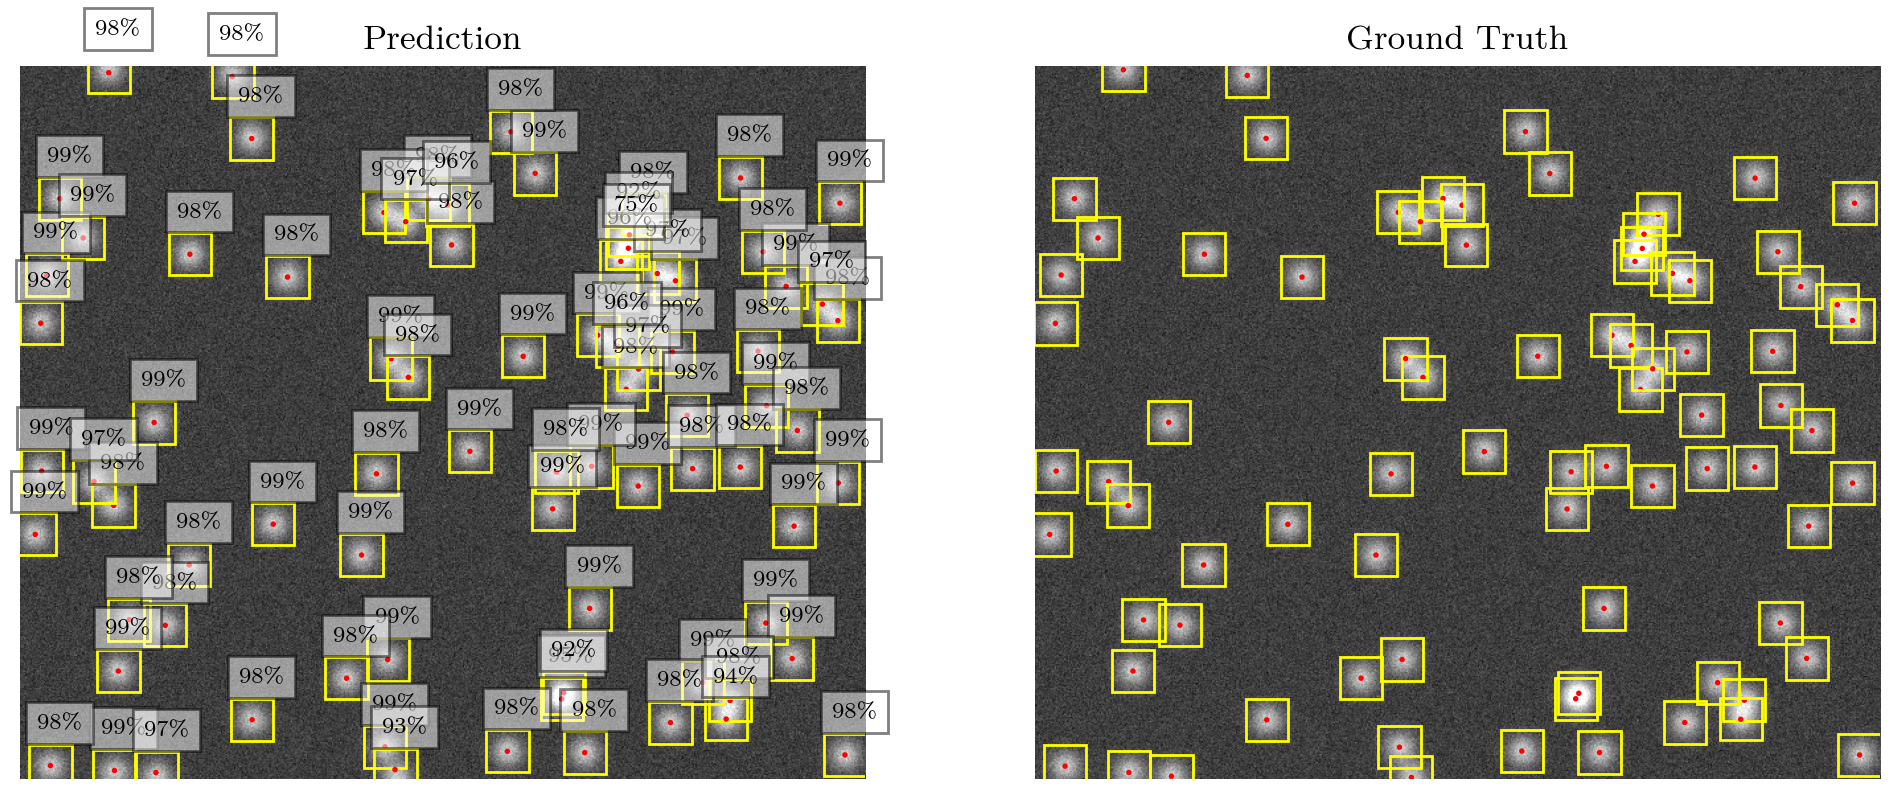

In [35]:
if not plt.get_fignums() : plt.figure(figsize=(12,5))
else: plt.clf()
image = random_image()
img = np.array(PIL.Image.open(image))
results = model.predict(np.array(img), conf = 0.7)
res = results[0].zaxis.data.cpu().numpy()
plt.subplot(1,2,1)
plt.title("Prediction")
kpt = res[:,8:]
bbox = res[:,:4]
z = np.zeros((len(res)))
plot_result(plt.gca(),img,res[:,4],ops.xyxy2xywh(bbox),z,kpt,conf=res[:,4], vmin=None, vmax=None)
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Ground Truth")
plot_gt(image,plt.gca(),imgsz, vmin=None, vmax=None)
plt.show()



Next, lets look at the validation scores

In [ ]:
snr_range = [1,20]
snrlevels = np.linspace(*snr_range, 20)
r,xy_rms, z_rms = [],[],[]
for i, snr in enumerate(snrlevels):
    fname = f'../datasets/Dataset_spots/levels/dataset_test_snr{snr}.yaml'
    res = model.val(conf=0.7,data=fname, workers=0, background_level=0)
    r.append(res.all_box_results)
    xy_rms.append(res.xy_rms)
    z_rms.append(res.z_rms)

    del res

Ultralytics 8.3.79 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 118 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_spots/labels/test_snr1.cache... 1000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1000/1000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 63/63 [00:02<00:00, 23.24it/s]

                   all       1000      59338      0.806      0.955      0.935      0.719   3.28e+04       2.24
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.3ms postprocess per image
Ultralytics 8.3.79 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)



val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_spots/labels/test_snr2.cache... 1000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1000/1000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 63/63 [00:02<00:00, 27.50it/s]


                   all       1000      60176      0.996      0.997      0.995      0.936   3.28e+04      0.882
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.79 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)


...

                   all       1000      59973          1      0.992      0.995      0.994   3.28e+04        0.2
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.79 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)



val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_spots/labels/test_snr19.cache... 1000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1000/1000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 63/63 [00:02<00:00, 30.66it/s]

                   all       1000      60538          1      0.993      0.995      0.994   3.28e+04      0.201
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.79 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)



val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_spots/labels/test_snr20.cache... 1000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1000/1000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 63/63 [00:02<00:00, 30.49it/s]

                   all       1000      59593          1      0.993      0.995      0.995   3.28e+04      0.195
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image


CRLB: [     1.2899      1.2899]


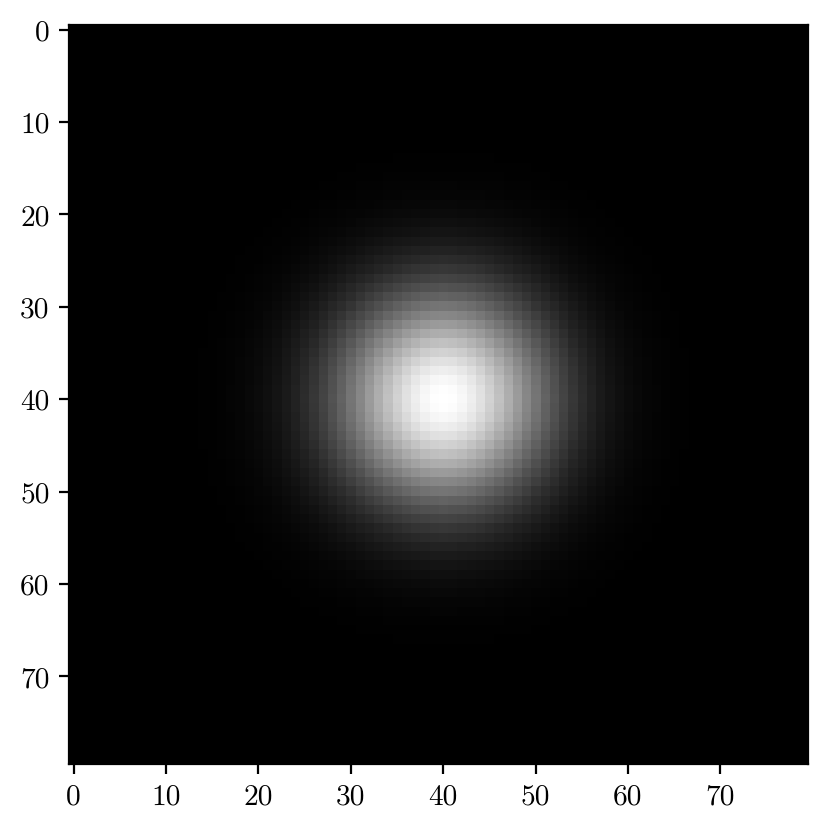

In [39]:
# calculate the CRLB
import image_generator as ig
objects = ig.pd.DataFrame({"label":"Spot", "i":2**15, "s":8, "x":40,"y":40}, index=[0])
img, _ = ig.generateImage(objects, (80,80),noise=0, refstack=np.zeros((40,40,40)))
plt.imshow(img, cmap='gray')
img /= img.max()
def derivative(psf, axis, delta=1e-2): # delta : small shift in x or y
    shift_vec = [0, 0]
    shift_vec[axis] = delta
    psf_forward = (1-delta)*psf+delta*np.roll(psf, shift=1, axis=axis)
    shift_vec[axis] = -delta
    psf_backward = (1-delta)*psf+delta*np.roll(psf, shift=-1, axis=axis)
    return (psf_forward - psf_backward) / (2 * delta)
dh_dx = derivative(img, axis=1)  # x-axis derivative
dh_dy = derivative(img, axis=0)  # y-axis derivative

# Compute Fisher Information Matrix (FIM)
I_xx =  np.sum(dh_dx**2)
I_yy =  np.sum(dh_dy**2)


I_xy =  np.sum(dh_dx * dh_dy)

FIM = np.array([[I_xx, I_xy],
                [I_xy, I_yy]])
CRLB = np.sqrt(np.diag(np.linalg.inv(FIM)))
print(f"CRLB: {CRLB}")

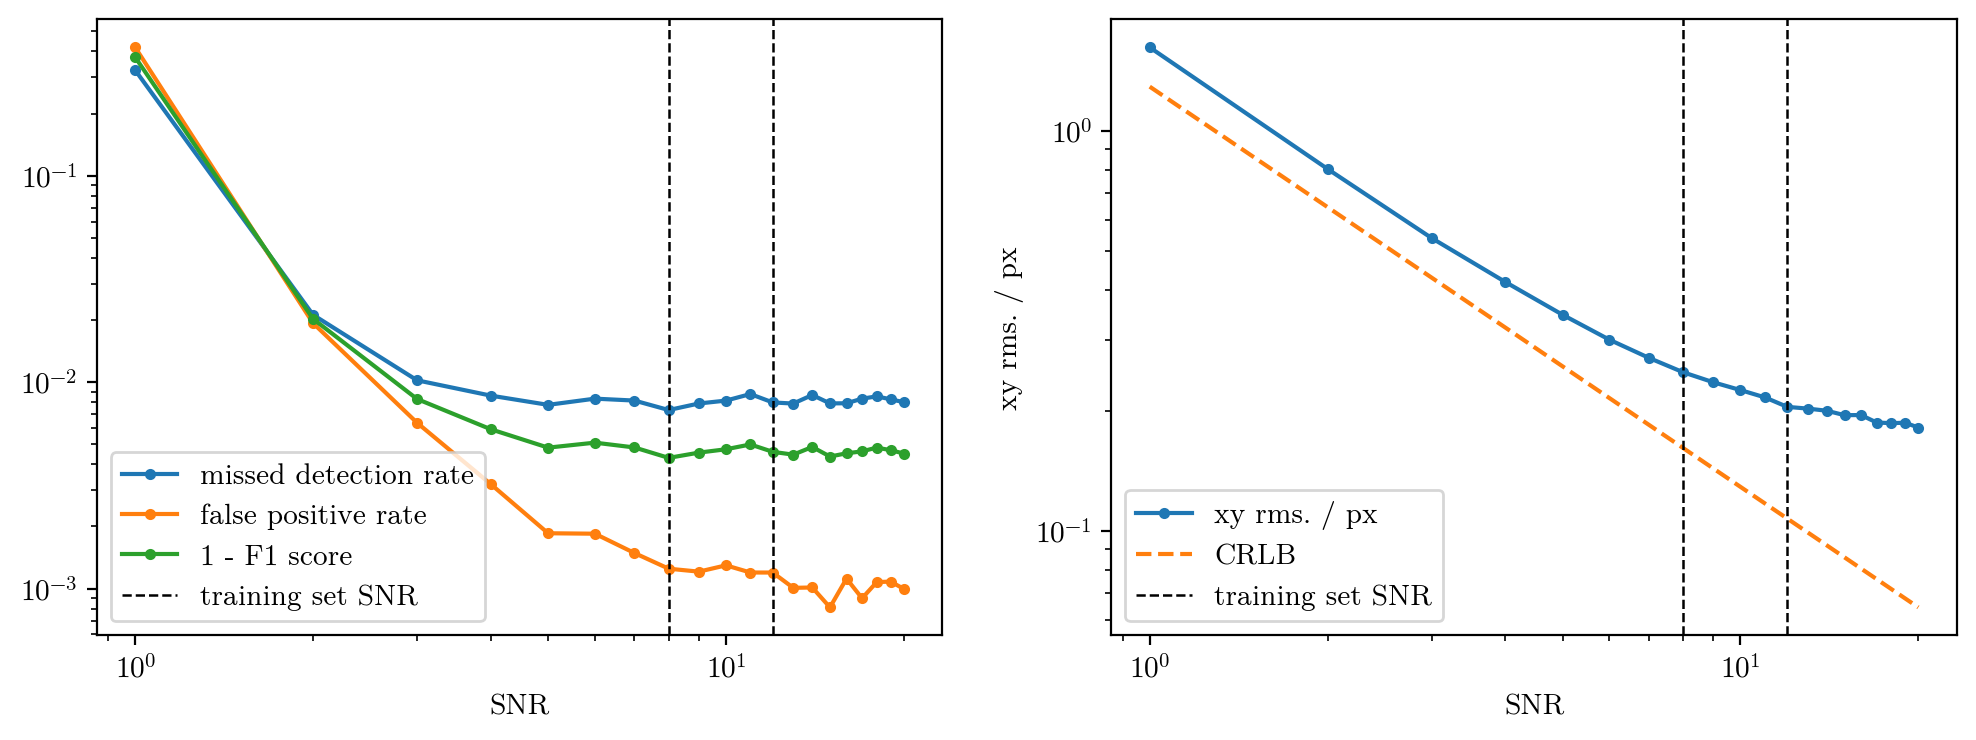

In [ ]:
recall = np.array([res["r"] for res in r]).squeeze()
precision = np.array([res["p"] for res in r]).squeeze()
f1 = 2 * (recall * precision) / (recall + precision)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)

plt.plot(snrlevels, 1-recall[:,7], ".-",label="missed detection rate")
plt.plot(snrlevels, 1-precision[:,7], ".-",label="false positive rate")
plt.plot(snrlevels, 1-f1[:,7], ".-",label="1 - F1 score")
plt.axvline(8,0,1,ls="dashed", lw=0.9,c="k")
plt.axvline(12,0,1,ls="dashed", lw=0.9,c="k", label="training set SNR")
plt.xlabel("SNR")
plt.xscale("log")
plt.yscale("log")
plt.legend()

plt.subplot(1,2,2)
plt.plot(snrlevels, np.array(xy_rms)[:,7], ".-",label="xy rms. / px")
plt.plot(snrlevels, 1/snrlevels * CRLB.mean(), "--", label="CRLB")
plt.axvline(8,0,1,ls="dashed", lw=0.9,c="k")
plt.axvline(12,0,1,ls="dashed", lw=0.9,c="k", label="training set SNR")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("SNR")
plt.ylabel("xy rms. / px")
plt.show()